# Experiment 03 — PdO on HfO₂: Batch 1 first data & the anneal-capped redesign

First measurement delivery for the HfO₂ campaign: **5 conditions × 3 replicates** with Hall
mobility and carrier concentration. This notebook:

1. **Records the received data** (transcribed from the delivered table, 2026-07-31 — replace the
   inline table with the file once it lands in `raw_data_received/`).
2. **Compares it against the generated DoE** (`output/experiment03_hfo2_doe_design/PdO_HfO2_LHS_SA_design.xlsx`)
   to confirm the fabricated conditions match the design.
3. **Analyzes the results** — three of the five conditions returned `<Contact Fail>` on every
   replicate. The failures separate cleanly from the successes by **vacuum-anneal temperature**:
   successes annealed at 75 and 250 °C, failures at 325, 440 and 410 °C.
4. **Re-poses the design problem** with the fab team's new process constraint
   **`Vac Ann Temp ≤ 300 °C`** and generates a **brand-new 23-condition LHS+SA design** under the
   capped bounds — a fresh design that does not condition on the previous table.

**Interpretation of the failures.** `<Contact Fail>` means no Hall measurement was possible —
the film at those conditions is not electrically continuous/contactable. Every run respected the
individual < 500 °C caps (nominal PdO/HfO₂ decomposition onset ~510 °C), yet 3/5 conditions
failed. The fab team's reading: the **vacuum-anneal step is the culprit** — in vacuum, PdO
decomposes at much lower temperatures than in oxygen, so the anneal must be capped at 300 °C.
This mirrors the experiment02 (Al₂O₃) precedent, where Batch 2 capped *only* the vacuum-anneal
temperature (at 550 °C there) for the same reason.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import qmc
import warnings; warnings.filterwarnings('ignore')

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)
OUT_DIR = 'output/experiment03_hfo2_batch1_analysis'
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

DESIGN_PATH = 'output/experiment03_hfo2_doe_design/PdO_HfO2_LHS_SA_design.xlsx'
print('Outputs ->', OUT_DIR)

Outputs -> output/experiment03_hfo2_batch1_analysis


## 1. Received data

Transcribed from the delivered results table (5 conditions × 3 replicates). `<Contact Fail>` is
recorded as `Contact_Fail = True` with `NaN` responses.

In [2]:
FACTOR_COLS = ['Dep Power (W)', 'O2 Flow (sccm)', 'Dep Press (mTorr)', 'Ox Temp (°C)',
               'Ox Press (atm)', 'Ox Time (min)', 'Vac Ann Temp (°C)', 'Vac Ann Time (min)',
               'Dep Thickness (nm)', 'Dep Temp (°C)']

# Base_Run_ID -> factor settings as delivered
received_conditions = {
    1: [ 7,  4.6, 8.2, 330, 0.02, 101.6, 325, 32.9, 2.6, 425],
    2: [36,  9.7, 4.3, 330, 0.01,   4.0, 440, 53.1, 2.7, 425],
    3: [24,  9.0, 9.7, 200, 0.02,   9.3, 250, 17.2, 4.1, 425],
    4: [37, 16.6, 6.3, 355, 0.01,  88.3,  75,  9.9, 2.5, 425],
    5: [23,  7.0, 9.4, 435, 0.01,  95.7, 410, 98.9, 3.4, 425],
}
# Base_Run_ID -> [(Hall mobility cm^2/V*s, carrier concentration #/cm^3)] per replicate; None = <Contact Fail>
received_results = {
    1: [None, None, None],
    2: [None, None, None],
    3: [(9.92, 4.06e19), (6.04, 1.53e20), (5.76, 1.30e20)],
    4: [(4.55, 2.01e20), (7.20, 7.53e19), (8.24, 1.47e20)],
    5: [None, None, None],
}

rows = []
for rid, factors in received_conditions.items():
    for rep, res in enumerate(received_results[rid], start=1):
        row = {'Base_Run_ID': rid, 'Replicate': rep, **dict(zip(FACTOR_COLS, factors))}
        row['Contact_Fail'] = res is None
        row['Hall Mobility (cm^2/V*s)']   = np.nan if res is None else res[0]
        row['Carrier Concentration (#/cm^3)'] = np.nan if res is None else res[1]
        rows.append(row)
received = pd.DataFrame(rows)
received.to_excel(os.path.join(OUT_DIR, 'received_batch1_transcribed.xlsx'), index=False)
print(f'{received.Base_Run_ID.nunique()} conditions x 3 replicates = {len(received)} rows | '
      f'contact failures: {int(received.Contact_Fail.sum())}/{len(received)} rows '
      f'({received[received.Contact_Fail].Base_Run_ID.nunique()}/5 conditions)')
received

5 conditions x 3 replicates = 15 rows | contact failures: 9/15 rows (3/5 conditions)


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C),Contact_Fail,Hall Mobility (cm^2/V*s),Carrier Concentration (#/cm^3)
0,1,1,7,4.6,8.2,330,0.02,101.6,325,32.9,2.6,425,True,NaN,NaN
1,1,2,7,4.6,8.2,330,0.02,101.6,325,32.9,2.6,425,True,NaN,NaN
2,1,3,7,4.6,8.2,330,0.02,101.6,325,32.9,2.6,425,True,NaN,NaN
3,2,1,36,9.7,4.3,330,0.01,4.0,440,53.1,2.7,425,True,NaN,NaN
4,2,2,36,9.7,4.3,330,0.01,4.0,440,53.1,2.7,425,True,NaN,NaN
5,2,3,36,9.7,4.3,330,0.01,4.0,440,53.1,2.7,425,True,NaN,NaN
6,3,1,24,9.0,9.7,200,0.02,9.3,250,17.2,4.1,425,False,9.92,4.060000e+19
7,3,2,24,9.0,9.7,200,0.02,9.3,250,17.2,4.1,425,False,6.04,1.530000e+20
8,3,3,24,9.0,9.7,200,0.02,9.3,250,17.2,4.1,425,False,5.76,1.300000e+20
9,4,1,37,16.6,6.3,355,0.01,88.3,75,9.9,2.5,425,False,4.55,2.010000e+20


## 2. Comparison against the generated DoE

The delivered conditions should be the first 5 base runs of the exported LHS+SA design. We check
every factor column of every condition against `design_unique`.

In [3]:
design = pd.read_excel(DESIGN_PATH, sheet_name='design_unique')
chk = received.drop_duplicates('Base_Run_ID').merge(
    design, on='Base_Run_ID', suffixes=(' (received)', ' (design)'))

report = []
for c in FACTOR_COLS:
    diff = ~np.isclose(chk[f'{c} (received)'].astype(float), chk[f'{c} (design)'].astype(float))
    report.append({'factor': c,
                   'match': 'EXACT' if not diff.any() else 'MISMATCH',
                   'mismatched_runs': chk.loc[diff, 'Base_Run_ID'].tolist()})
report = pd.DataFrame(report)
all_ok = (report['match'] == 'EXACT').all()
print(f"All 5 delivered conditions vs design runs 1-5: "
      f"{'IDENTICAL on every factor - fabricated as designed' if all_ok else 'DEVIATIONS FOUND'}")
report

All 5 delivered conditions vs design runs 1-5: IDENTICAL on every factor - fabricated as designed


,factor,match,mismatched_runs
0,Dep Power (W),EXACT,[]
1,O2 Flow (sccm),EXACT,[]
2,Dep Press (mTorr),EXACT,[]
3,Ox Temp (°C),EXACT,[]
4,Ox Press (atm),EXACT,[]
5,Ox Time (min),EXACT,[]
6,Vac Ann Temp (°C),EXACT,[]
7,Vac Ann Time (min),EXACT,[]
8,Dep Thickness (nm),EXACT,[]
9,Dep Temp (°C),EXACT,[]


## 3. Results — the two measurable conditions

Replicate-level Hall mobility and carrier concentration for the conditions that produced
contactable films.

In [4]:
ok = received[~received.Contact_Fail]
summ = ok.groupby('Base_Run_ID').agg(
    ox_T=('Ox Temp (°C)', 'first'), ann_T=('Vac Ann Temp (°C)', 'first'),
    mob_mean=('Hall Mobility (cm^2/V*s)', 'mean'), mob_std=('Hall Mobility (cm^2/V*s)', 'std'),
    car_mean=('Carrier Concentration (#/cm^3)', 'mean'), car_std=('Carrier Concentration (#/cm^3)', 'std'))
summ['mob_CV_%'] = (100 * summ.mob_std / summ.mob_mean).round(1)
summ['car_CV_%'] = (100 * summ.car_std / summ.car_mean).round(1)
print('Replicate scatter is large (CV ~30-60%) - consistent with the SEM^2-noise GP treatment planned downstream.')
summ.round(3)

Replicate scatter is large (CV ~30-60%) - consistent with the SEM^2-noise GP treatment planned downstream.


,ox_T,ann_T,mob_mean,mob_std,car_mean,car_std,mob_CV_%,car_CV_%
Base_Run_ID,,,,,,,,
3,200,250,7.240,2.325,1.078667e+20,5.937890e+19,32.1,55.0
4,355,75,6.663,1.903,1.411000e+20,6.305735e+19,28.6,44.7


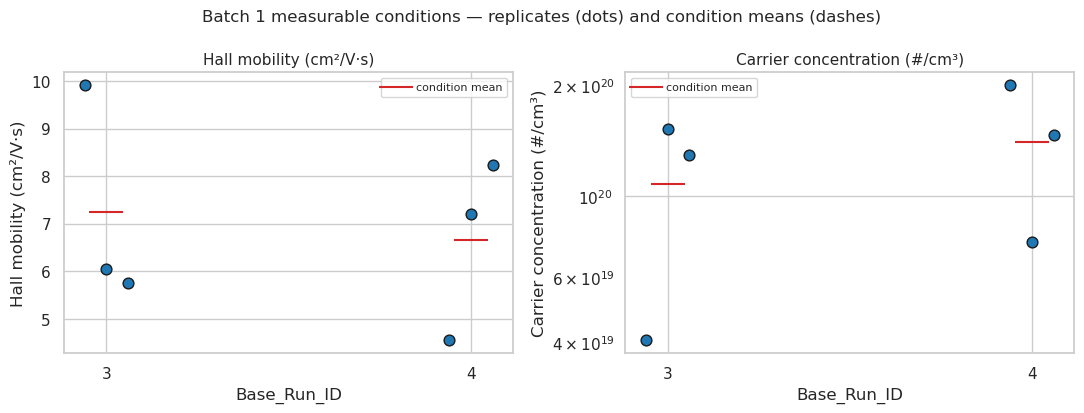

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, ylab, logy in [
        (axes[0], 'Hall Mobility (cm^2/V*s)', 'Hall mobility (cm²/V·s)', False),
        (axes[1], 'Carrier Concentration (#/cm^3)', 'Carrier concentration (#/cm³)', True)]:
    for rid, gdf in ok.groupby('Base_Run_ID'):
        x = np.full(len(gdf), rid) + np.linspace(-0.06, 0.06, len(gdf))
        ax.scatter(x, gdf[col], s=60, color='#1f77b4', edgecolor='k', zorder=3)
        ax.scatter([rid], [gdf[col].mean()], marker='_', s=600, color='#d62728', zorder=4,
                   label='condition mean' if rid == ok.Base_Run_ID.min() else None)
    if logy: ax.set_yscale('log')
    ax.set_xticks(sorted(ok.Base_Run_ID.unique()))
    ax.set_xlabel('Base_Run_ID'); ax.set_ylabel(ylab)
    ax.set_title(ylab, fontsize=11); ax.legend(fontsize=8)
fig.suptitle('Batch 1 measurable conditions — replicates (dots) and condition means (dashes)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'batch1_responses.png'), dpi=180, bbox_inches='tight')
plt.show()

## 4. Feasibility — the vacuum-anneal cap

With only 5 outcomes, several simple rules separate the failures from the successes equally well
(anneal ≤ 300 °C, thermal-budget sum ≤ 500 °C, "both temps high"). The fab team's process
knowledge resolves the ambiguity: **the vacuum-anneal step is the failure mechanism** — PdO
decomposes at far lower temperatures in vacuum than in oxygen — and the new process constraint is

$$\textbf{Vac Ann Temp} \le 300\,°\text{C}$$

The data is fully consistent: successes annealed at 75 and 250 °C, failures at 325, 410 and
440 °C. Oxidation temperature keeps its original 200–500 °C range (successful run #4 oxidized at
355 °C — hotter than failed run #1's 330 °C — so oxidation temperature is not implicated). This
also mirrors experiment02 on Al₂O₃, where Batch 2 capped *only* the vacuum-anneal (at 550 °C
there; lower here because the HfO₂ substrate lowers the decomposition onset).

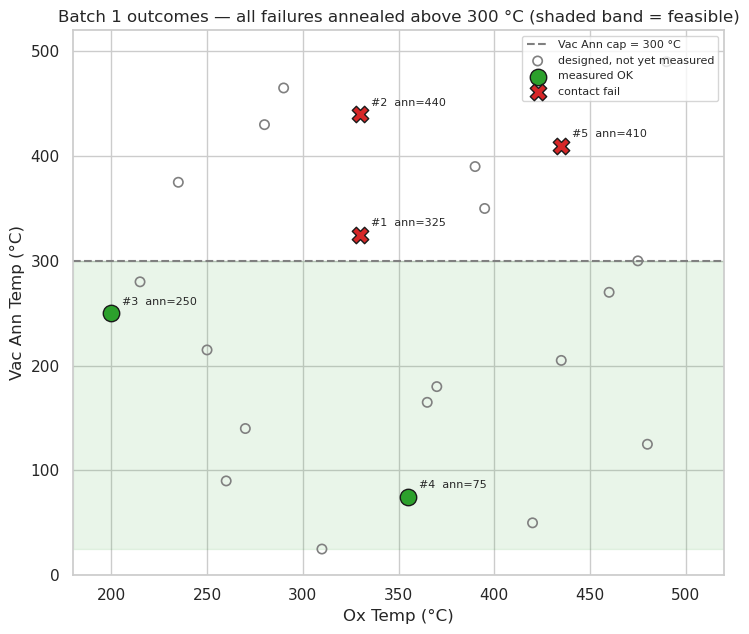

In [6]:
meas = received.drop_duplicates('Base_Run_ID').copy()
ANN_CAP = 300.0

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.axhspan(25, ANN_CAP, xmin=0, xmax=1, color='#2ca02c', alpha=0.10, zorder=1)
ax.axhline(ANN_CAP, ls='--', color='gray', lw=1.5, zorder=2, label=f'Vac Ann cap = {ANN_CAP:g} °C')
rest = design[~design.Base_Run_ID.isin(meas.Base_Run_ID)]
ax.scatter(rest['Ox Temp (°C)'], rest['Vac Ann Temp (°C)'], s=45, facecolor='none',
           edgecolor='gray', lw=1.2, zorder=3, label='designed, not yet measured')
for fail, mk, c, lbl in [(False, 'o', '#2ca02c', 'measured OK'),
                         (True, 'X', '#d62728', 'contact fail')]:
    sub = meas[meas.Contact_Fail == fail]
    ax.scatter(sub['Ox Temp (°C)'], sub['Vac Ann Temp (°C)'], marker=mk, s=140, color=c,
               edgecolor='k', zorder=4, label=lbl)
for _, r in meas.iterrows():
    ax.annotate(f"#{int(r.Base_Run_ID)}  ann={int(r['Vac Ann Temp (°C)'])}",
                (r['Ox Temp (°C)'], r['Vac Ann Temp (°C)']),
                textcoords='offset points', xytext=(8, 6), fontsize=8)
ax.set_xlim(180, 520); ax.set_ylim(0, 520)
ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Batch 1 outcomes — all failures annealed above 300 °C (shaded band = feasible)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feasibility_temperature_plane.png'), dpi=200, bbox_inches='tight')
plt.show()

In [7]:
# Impact of the anneal cap on the existing 23-condition design
dsg = design.copy()
dsg['feasible'] = dsg['Vac Ann Temp (°C)'] <= ANN_CAP
n_ok = int(dsg.feasible.sum())
print(f'Under Vac Ann <= {ANN_CAP:g} °C: {n_ok}/23 designed conditions remain feasible')
print('  feasible  :', dsg.loc[dsg.feasible,  'Base_Run_ID'].tolist())
print('  infeasible:', dsg.loc[~dsg.feasible, 'Base_Run_ID'].tolist())
print('Measured so far: #3, #4 feasible (data in hand); #1, #2, #5 infeasible (contact fail).')

Under Vac Ann <= 300 °C: 14/23 designed conditions remain feasible
  feasible  : [3, 4, 6, 8, 10, 11, 13, 14, 15, 17, 18, 19, 20, 21]
  infeasible: [1, 2, 5, 7, 9, 12, 16, 22, 23]
Measured so far: #3, #4 feasible (data in hand); #1, #2, #5 infeasible (contact fail).


## 5. The new setup — a brand-new anneal-capped DoE

The constraint is a plain bound change: **`Vac Ann Temp: 25 → 300 °C`** (was 25 → 500); every
other factor is untouched. The design machinery is therefore identical to the original study —
only `HFO2_CONFIG` changes.

This is a **fresh design**: `conditional_sa_lhs` is called with an empty `fixed` block (which
reduces it to a plain discrepancy-optimized LHS + SA), generating **23 new conditions
(IDs 1–23) × 3 replicates = 69 rows** — it does not condition on the previous table. The
already-measured #3 and #4 from the old design stay valid data points for the downstream GP
(they lie inside the new bounds), but the new DoE is designed independently of them.

In [8]:
GLOBAL_SEED, N_CONDITIONS, NUM_REPLICATES, DEP_TEMP_FIXED = 20, 23, 3, 425.0

HFO2_CONFIG = {
    'Dep Power (W)':      {'min': 2.0,   'max': 40.0,  'step': 1.0},
    'O2 Flow (sccm)':     {'gap_prob': 0.10, 'gap_val': 0.0, 'min': 0.3, 'max': 20.0, 'step': 0.1},
    'Dep Press (mTorr)':  {'min': 2.0,   'max': 10.0,  'step': 0.1},
    'Ox Temp (°C)':       {'min': 200.0, 'max': 500.0, 'step': 5.0},
    'Ox Press (atm)':     [0.01, 0.02],
    'Ox Time (min)':      {'min': 0.0,   'max': 120.0, 'step': 0.1},
    'Vac Ann Temp (°C)':  {'min': 25.0,  'max': 300.0, 'step': 5.0},   # NEW CAP (was 500)
    'Vac Ann Time (min)': {'min': 0.0,   'max': 120.0, 'step': 0.1},
    'Dep Thickness (nm)': {'min': 2.0,   'max': 6.0,   'step': 0.1},
}
FACTORS = list(HFO2_CONFIG.keys()); d = len(FACTORS)

def map_parameter(u, s):
    if isinstance(s, list):
        return s[min(int(u * len(s)), len(s) - 1)]
    if s.get('gap_prob', 0) > 0 and u < s['gap_prob']:
        return s['gap_val']
    if 'gap_prob' in s and s['gap_prob'] > 0:
        u = (u - s['gap_prob']) / (1 - s['gap_prob'])
    val = s['min'] + u * (s['max'] - s['min'])
    return round(round(val / s['step']) * s['step'], 4) if 'step' in s else round(val, 4)

def to_physical(U):
    return pd.DataFrame([[map_parameter(U[r, i], HFO2_CONFIG[FACTORS[i]]) for i in range(d)]
                         for r in range(len(U))], columns=FACTORS)

def optimized_lhs(n, dim, seed):
    return qmc.LatinHypercube(d=dim, optimization='random-cd', seed=seed).random(n)

def _swap(P, col, a, b):
    P[[a, b], col] = P[[b, a], col]

def conditional_sa_lhs(fixed, n_new, dim, seed, n_iter=12000, T_end=1e-3):
    rng = np.random.default_rng(seed)
    P = optimized_lhs(n_new, dim, seed)
    score = lambda: qmc.discrepancy(np.vstack([fixed, P]) if len(fixed) else P)
    cur = best = score(); best_P = P.copy()
    ups = []
    for _ in range(200):
        c = rng.integers(dim); a, b = rng.choice(n_new, 2, replace=False)
        _swap(P, c, a, b); delta = score() - cur; _swap(P, c, a, b)
        if delta > 0: ups.append(delta)
    T = float(np.mean(ups)) if ups else 1e-3
    alpha = T_end ** (1.0 / n_iter)
    for _ in range(n_iter):
        c = rng.integers(dim); a, b = rng.choice(n_new, 2, replace=False)
        _swap(P, c, a, b); cand = score(); delta = cand - cur
        if delta < 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            cur = cand
            if cur < best: best, best_P = cur, P.copy()
        else:
            _swap(P, c, a, b)
        T *= alpha
    return best_P

U_new = conditional_sa_lhs(np.empty((0, d)), N_CONDITIONS, d, GLOBAL_SEED, n_iter=12000)
design_new = to_physical(U_new)
design_new['Dep Temp (°C)'] = DEP_TEMP_FIXED
design_new.insert(0, 'Base_Run_ID', range(1, N_CONDITIONS + 1))
design_new['Batch'] = 'Batch 1 (anneal-capped)'

assert (design_new['Vac Ann Temp (°C)'] <= ANN_CAP).all(), 'anneal cap violated'
print(f'Brand-new design: {N_CONDITIONS} conditions (IDs 1-{N_CONDITIONS}) '
      f'x {NUM_REPLICATES} replicates = {N_CONDITIONS * NUM_REPLICATES} rows')
print(f"Vac Ann range: [{design_new['Vac Ann Temp (°C)'].min():.0f}, "
      f"{design_new['Vac Ann Temp (°C)'].max():.0f}] °C (cap {ANN_CAP:g}) | "
      f'cube discrepancy = {qmc.discrepancy(U_new):.4f}')
design_new

Brand-new design: 23 conditions (IDs 1-23) x 3 replicates = 69 rows
Vac Ann range: [25, 295] °C (cap 300) | cube discrepancy = 0.0681


,Base_Run_ID,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C),Batch
0,1,7.0,4.6,8.2,330.0,0.02,101.6,200.0,32.9,2.6,425.0,Batch 1 (anneal-capped)
1,2,36.0,9.7,4.3,330.0,0.01,4.0,265.0,53.1,2.7,425.0,Batch 1 (anneal-capped)
2,3,24.0,9.0,9.7,200.0,0.02,9.3,155.0,17.2,4.1,425.0,Batch 1 (anneal-capped)
3,4,37.0,16.6,6.3,355.0,0.01,88.3,55.0,9.9,2.5,425.0,Batch 1 (anneal-capped)
4,5,23.0,7.0,9.4,435.0,0.01,95.7,250.0,98.9,3.4,425.0,Batch 1 (anneal-capped)
5,6,21.0,0.9,3.3,435.0,0.02,73.7,130.0,49.0,2.2,425.0,Batch 1 (anneal-capped)
6,7,10.0,8.0,2.9,280.0,0.01,56.6,260.0,12.4,5.8,425.0,Batch 1 (anneal-capped)
7,8,27.0,17.5,2.0,475.0,0.01,61.4,185.0,36.6,3.9,425.0,Batch 1 (anneal-capped)
8,9,4.0,15.5,5.9,390.0,0.02,43.6,235.0,112.4,3.0,425.0,Batch 1 (anneal-capped)
9,10,19.0,3.0,6.6,260.0,0.01,71.7,65.0,30.8,5.4,425.0,Batch 1 (anneal-capped)


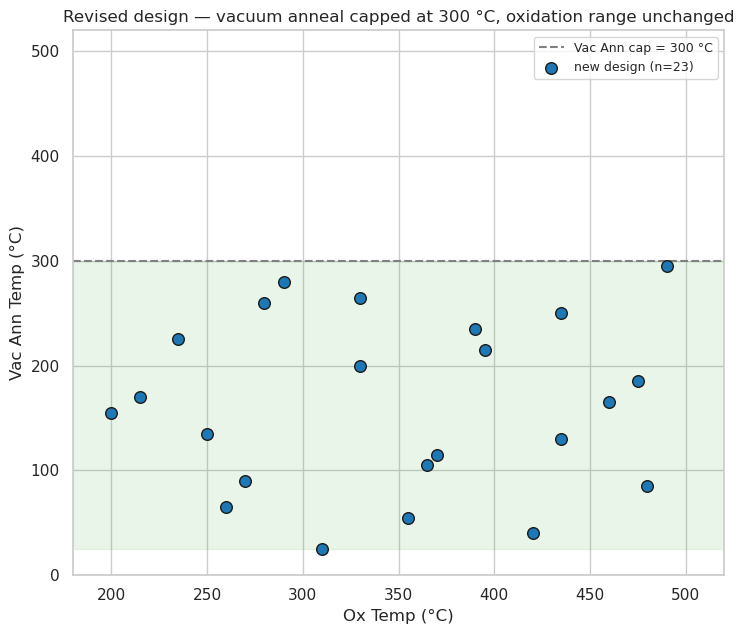

In [9]:
# The revised design on the temperature plane
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.axhspan(25, ANN_CAP, color='#2ca02c', alpha=0.10, zorder=1)
ax.axhline(ANN_CAP, ls='--', color='gray', lw=1.5, zorder=2, label=f'Vac Ann cap = {ANN_CAP:g} °C')
ax.scatter(design_new['Ox Temp (°C)'], design_new['Vac Ann Temp (°C)'], s=70, color='#1f77b4',
           edgecolor='k', zorder=3, label=f'new design (n={len(design_new)})')
ax.set_xlim(180, 520); ax.set_ylim(0, 520)
ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Revised design — vacuum anneal capped at 300 °C, oxidation range unchanged')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'redesign_temperature_plane.png'), dpi=200, bbox_inches='tight')
plt.show()

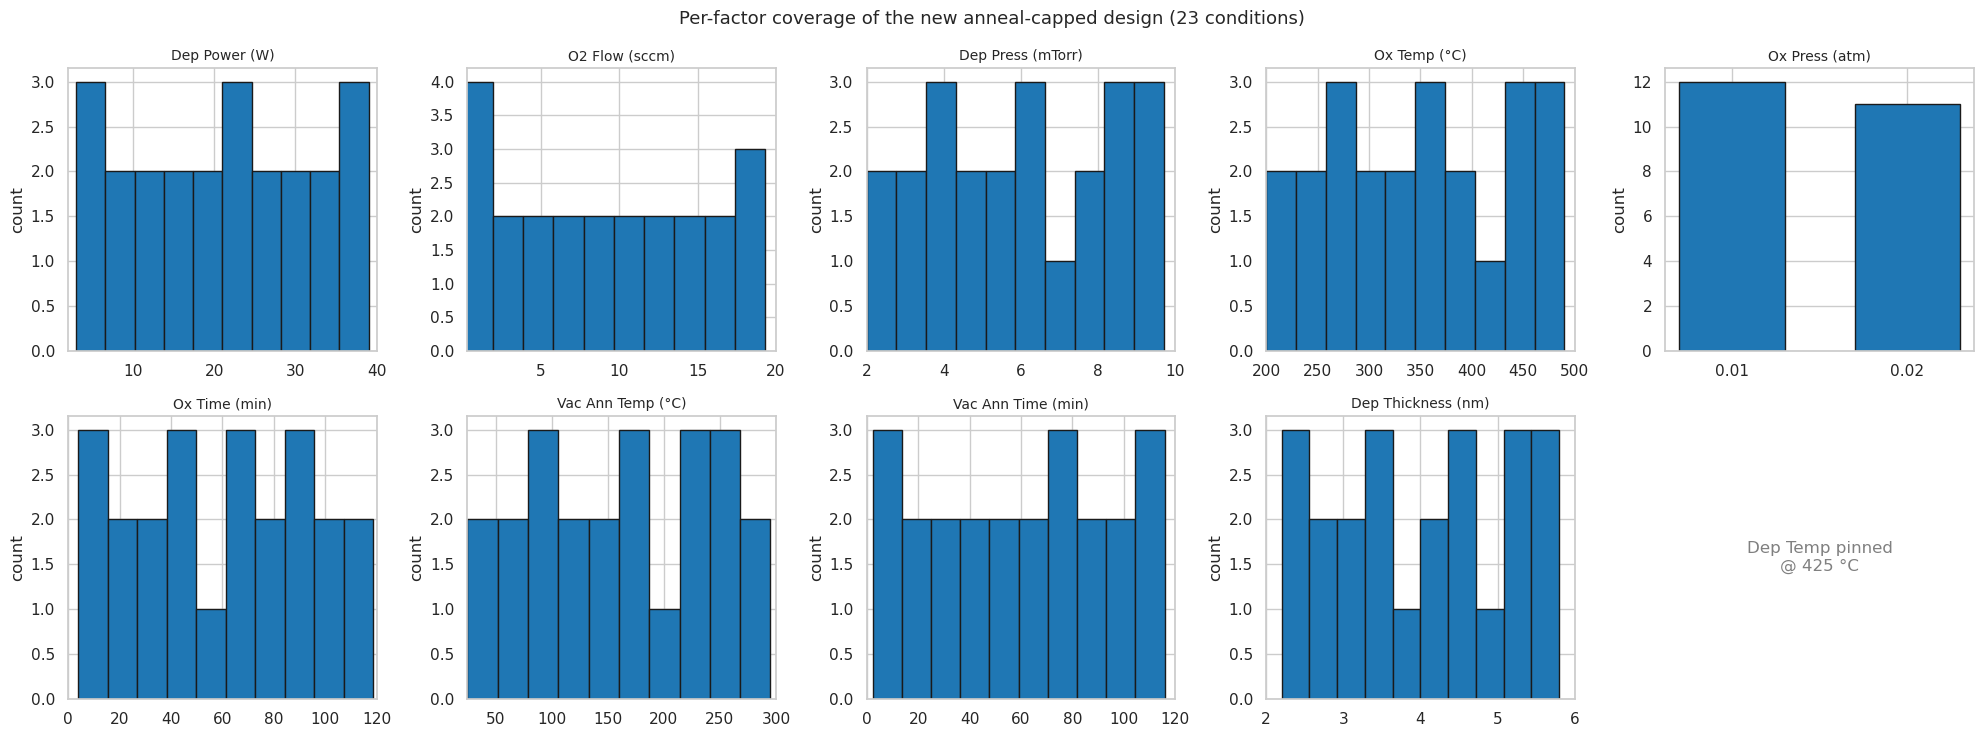

In [10]:
# Per-factor coverage of the new 23-condition design
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
for ax, f in zip(axes.flat, FACTORS):
    s = HFO2_CONFIG[f]
    if isinstance(s, list):
        lv = sorted(s); ax.bar([str(x) for x in lv], [int((design_new[f] == x).sum()) for x in lv],
                               color='#1f77b4', edgecolor='k', width=0.6)
    else:
        ax.hist(design_new[f], bins=10, color='#1f77b4', edgecolor='k'); ax.set_xlim(s['min'], s['max'])
    ax.set_title(f, fontsize=10); ax.set_ylabel('count')
axes.flat[9].axis('off')
axes.flat[9].text(0.5, 0.5, f'Dep Temp pinned\n@ {DEP_TEMP_FIXED:g} °C', ha='center', va='center',
                  fontsize=12, color='gray')
fig.suptitle(f'Per-factor coverage of the new anneal-capped design ({N_CONDITIONS} conditions)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'redesign_factor_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()

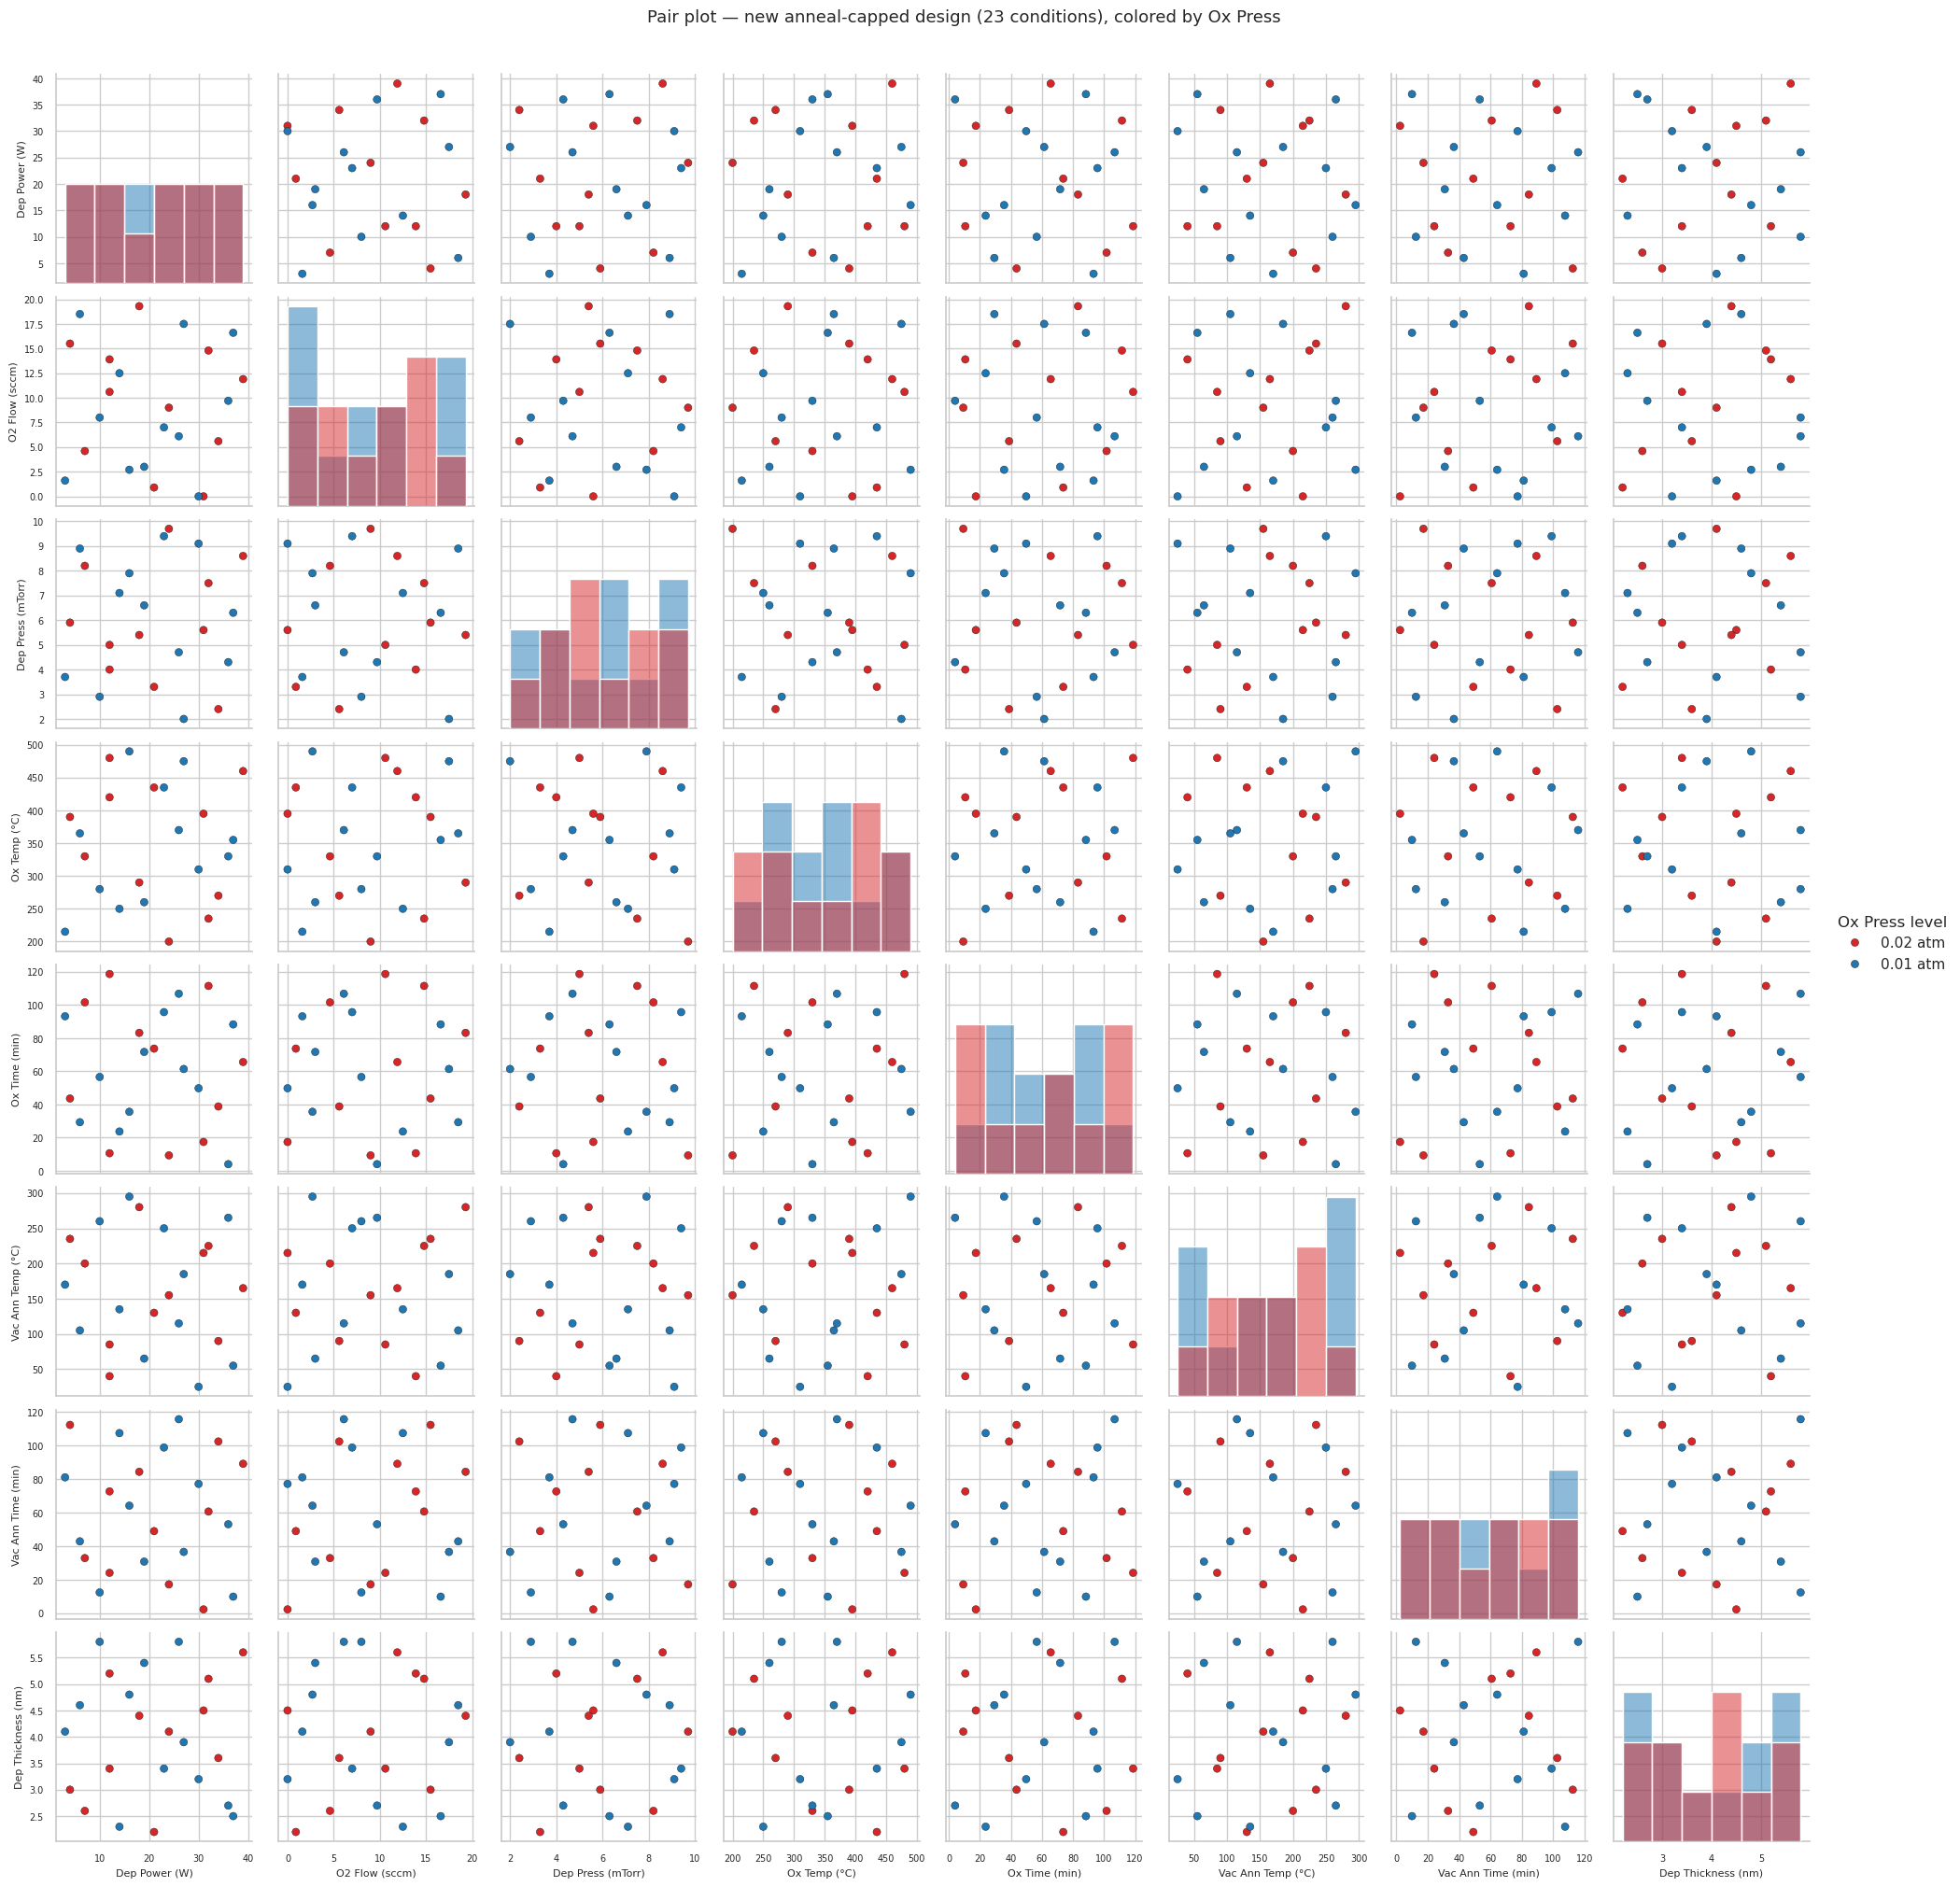

Ox Press split: {'0.01 atm': 12, '0.02 atm': 11}


In [11]:
# Pair plot of the new 23-condition design
pp = design_new.copy()
pp['Ox Press level'] = pp['Ox Press (atm)'].round(2).map({0.01: '0.01 atm', 0.02: '0.02 atm'})
pvars = [f for f in FACTORS if f != 'Ox Press (atm)']
g = sns.pairplot(pp, vars=pvars, hue='Ox Press level', corner=False, diag_kind='hist',
                 palette={'0.01 atm': '#1f77b4', '0.02 atm': '#d62728'},
                 plot_kws=dict(s=34, edgecolor='k', linewidth=0.3))
g.fig.suptitle('Pair plot — new anneal-capped design (23 conditions), colored by Ox Press',
               y=1.02, fontsize=13)
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=7); ax.xaxis.label.set_size(8); ax.yaxis.label.set_size(8)
g.savefig(os.path.join(OUT_DIR, 'redesign_pairplot.png'), dpi=170, bbox_inches='tight')
plt.show()
print('Ox Press split:', pp['Ox Press level'].value_counts().to_dict())

## 6. Export the new fabrication design

Full run sheet: 23 conditions × 3 replicates = 69 rows, plus config and provenance sheets.

In [12]:
design_new_full = design_new.loc[design_new.index.repeat(NUM_REPLICATES)].reset_index(drop=True)
design_new_full.insert(1, 'Replicate', design_new_full.groupby('Base_Run_ID').cumcount() + 1)

cfg_rows = []
for f, s in HFO2_CONFIG.items():
    if isinstance(s, list):
        cfg_rows.append({'factor': f, 'min': min(s), 'max': max(s), 'step': '—', 'levels': str(s)})
    else:
        note = f"gap_val={s['gap_val']} (p={s['gap_prob']})" if s.get('gap_prob') else '—'
        if f == 'Vac Ann Temp (°C)':
            note = 'NEW: capped at 300 °C (was 500) — fab-team process constraint'
        cfg_rows.append({'factor': f, 'min': s['min'], 'max': s['max'], 'step': s.get('step'),
                         'levels': note})
cfg_rows.append({'factor': 'Dep Temp (°C)', 'min': DEP_TEMP_FIXED, 'max': DEP_TEMP_FIXED,
                 'step': '—', 'levels': 'pinned'})
prov = pd.DataFrame([
    {'property': 'design method', 'value': 'LHS + simulated annealing (fresh design, empty fixed block)'},
    {'property': 'constraint', 'value': 'Vac Ann Temp <= 300 °C (fab-team process constraint after the first delivery)'},
    {'property': 'evidence', 'value': 'prior runs with ann 250,75 °C measured OK; ann 325,440,410 °C contact-failed'},
    {'property': 'conditions', 'value': f'{N_CONDITIONS} (IDs 1-{N_CONDITIONS}), x{NUM_REPLICATES} replicates = {len(design_new_full)} rows'},
    {'property': 'seed', 'value': GLOBAL_SEED},
    {'property': 'supersedes', 'value': 'PdO_HfO2_LHS_SA_design.xlsx (old bounds; brand-new design, not conditioned on it)'},
])
out_path = os.path.join(OUT_DIR, 'PdO_HfO2_LHS_SA_design_v2_anncap300.xlsx')
with pd.ExcelWriter(out_path) as w:
    design_new_full.to_excel(w, sheet_name='design_full',   index=False)
    design_new.to_excel(w,      sheet_name='design_unique', index=False)
    pd.DataFrame(cfg_rows).to_excel(w, sheet_name='config', index=False)
    prov.to_excel(w,            sheet_name='provenance',    index=False)
print('Saved:', out_path)
design_new_full.head(6)

Saved: output/experiment03_hfo2_batch1_analysis/PdO_HfO2_LHS_SA_design_v2_anncap300.xlsx


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C),Batch
0,1,1,7.0,4.6,8.2,330.0,0.02,101.6,200.0,32.9,2.6,425.0,Batch 1 (anneal-capped)
1,1,2,7.0,4.6,8.2,330.0,0.02,101.6,200.0,32.9,2.6,425.0,Batch 1 (anneal-capped)
2,1,3,7.0,4.6,8.2,330.0,0.02,101.6,200.0,32.9,2.6,425.0,Batch 1 (anneal-capped)
3,2,1,36.0,9.7,4.3,330.0,0.01,4.0,265.0,53.1,2.7,425.0,Batch 1 (anneal-capped)
4,2,2,36.0,9.7,4.3,330.0,0.01,4.0,265.0,53.1,2.7,425.0,Batch 1 (anneal-capped)
5,2,3,36.0,9.7,4.3,330.0,0.01,4.0,265.0,53.1,2.7,425.0,Batch 1 (anneal-capped)


## Output files

All under `output/experiment03_hfo2_batch1_analysis/`:

* `received_batch1_transcribed.xlsx` — the delivered results, transcribed (replace with the raw
  file when it lands in `raw_data_received/`).
* `batch1_responses.png` — replicate-level mobility / carrier concentration for #3 and #4.
* `feasibility_temperature_plane.png` — outcomes vs the 300 °C vacuum-anneal cap.
* **`PdO_HfO2_LHS_SA_design_v2_anncap300.xlsx`** — the new fabrication design (23 conditions
  × 3 replicates = 69 rows, IDs 1–23) + config + provenance.
* `redesign_temperature_plane.png`, `redesign_factor_distributions.png`, `redesign_pairplot.png`
  — new-design diagnostics.

**Next steps:** fabricate the new batch; as data returns, mirror `experiment02_pdo_analysis.ipynb`
(ANOVA, replicate CV, factor effects) and start the GP/qLogNEHVI loop
(`repository_dmref/utils/mobo.py`). The measured #3 and #4 from the old design lie inside the new
bounds and remain usable as extra data points for the GP, and `Contact Fail` outcomes can feed a
feasibility model.